# TP1 - White Patch e Histogramas

**Alumno:** Alan Cornejo  
**Materia:** Visión por Computadora I

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)

In [39]:
white_patch_path = Path("white_patch")
img1_path = Path("img1_tp.png")
img2_path =  Path("img2_tp.png")


## Parte 1: Algoritmo White Patch


In [41]:
imagenes_wp = sorted(list(white_patch_path.glob("*")))

In [42]:
def white_patch(img_bgr):
    
    #aplica el algoritmo White Patch a una imagen en formato BGR
    
    # convertir a float para realizar operaciones matemáticas
    img_float = img_bgr.astype(np.float32)

    # separar canales
    B, G, R = cv2.split(img_float)

    # Obtener maximos por canal
    Bmax = np.max(B)
    Gmax = np.max(G)
    Rmax = np.max(R)

    # evitar division por cero
    if Bmax == 0:
        Bmax = 1
    if Gmax == 0:
        Gmax = 1
    if Rmax == 0:
        Rmax = 1

    # aplicar normalizacion white patch
    B_corr = B * 255.0 / Bmax
    G_corr = G * 255.0 / Gmax
    R_corr = R * 255.0 / Rmax

    # unir canales corregidos
    img_corr = cv2.merge([B_corr, G_corr, R_corr])

    # limitar al rango valido de una imagen de 8 bits
    img_corr = np.clip(img_corr, 0, 255).astype(np.uint8)

    return img_corr

In [43]:
resultados_wp = []

for img_path in imagenes_wp:
    img_original = cv2.imread(str(img_path))

    if img_original is None:
        print("no se pudo leer:", img_path.name)
        continue

    img_corregida = white_patch(img_original)

    resultados_wp.append({
        "nombre": img_path.name,
        "original": img_original,
        "corregida": img_corregida
    })

print("Imágenes procesadas:", len(resultados_wp))

Imágenes procesadas: 8


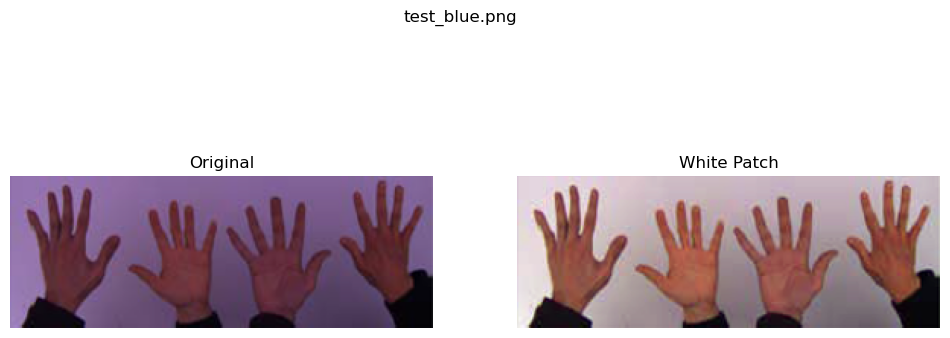

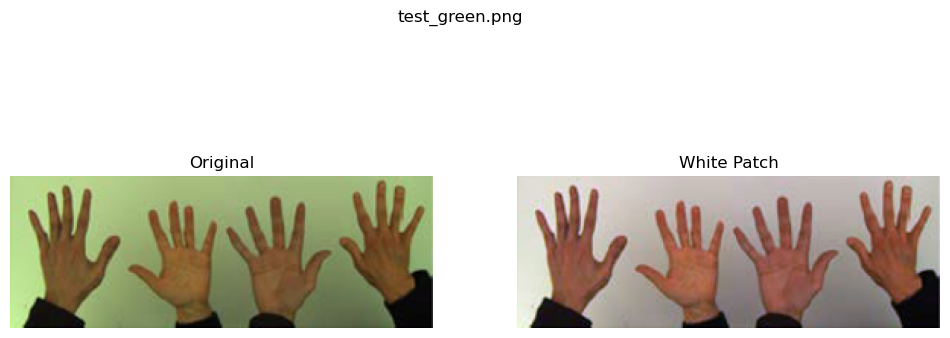

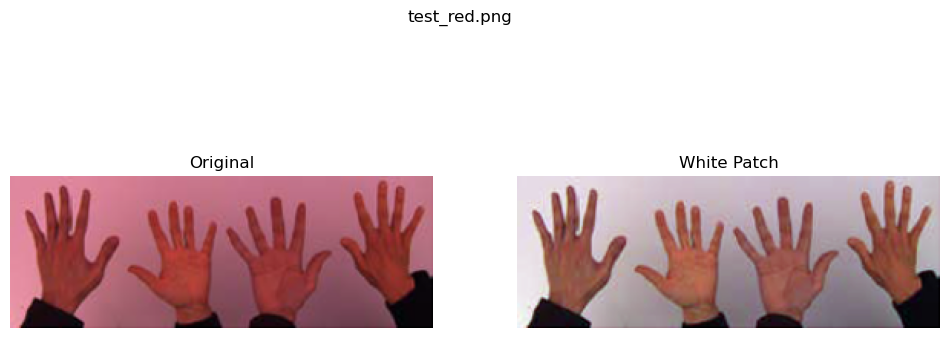

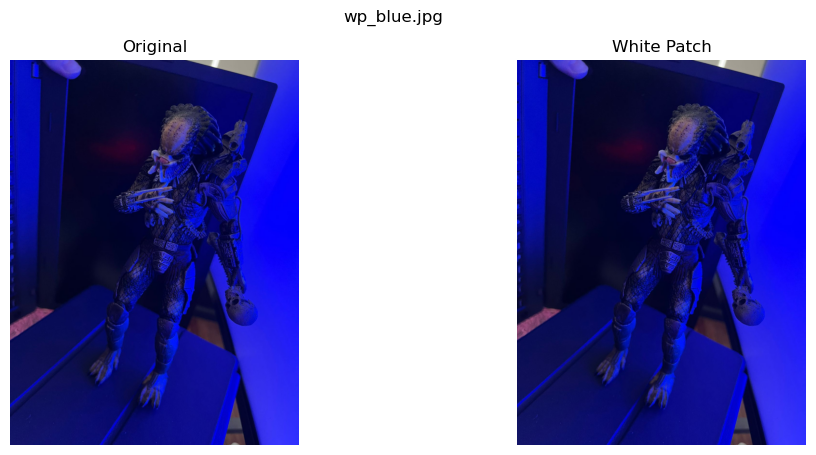

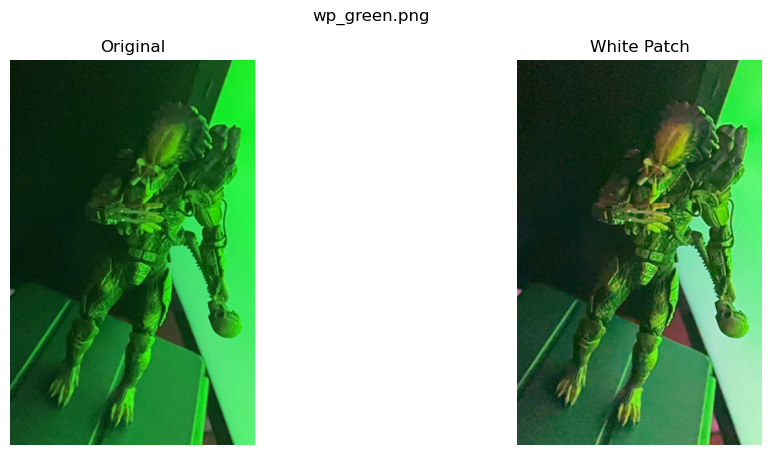

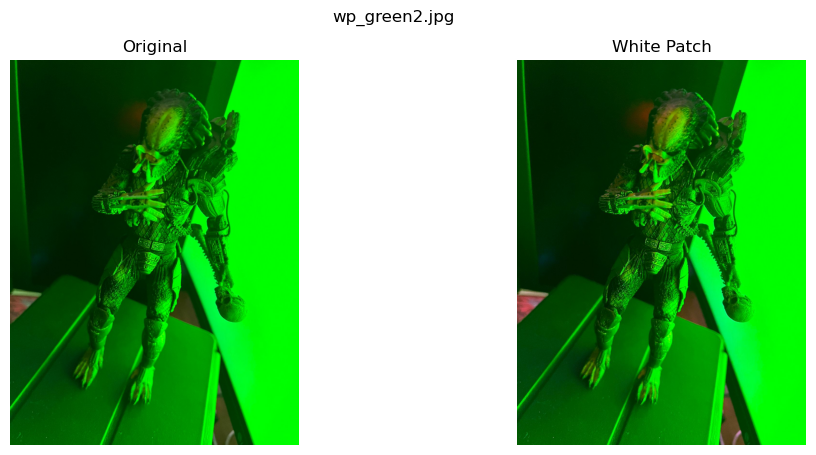

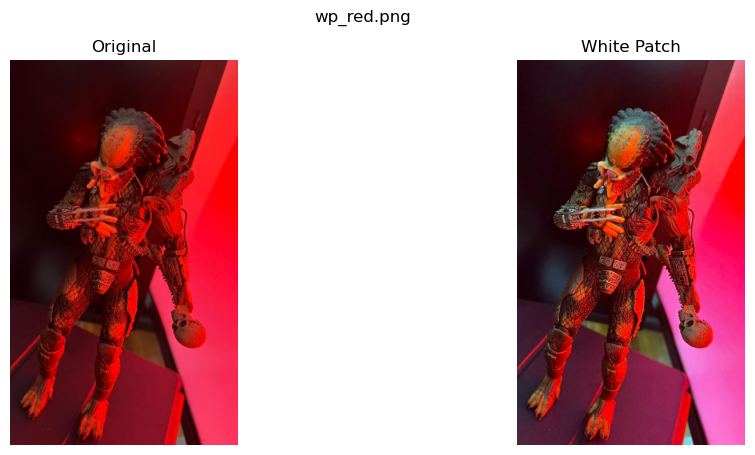

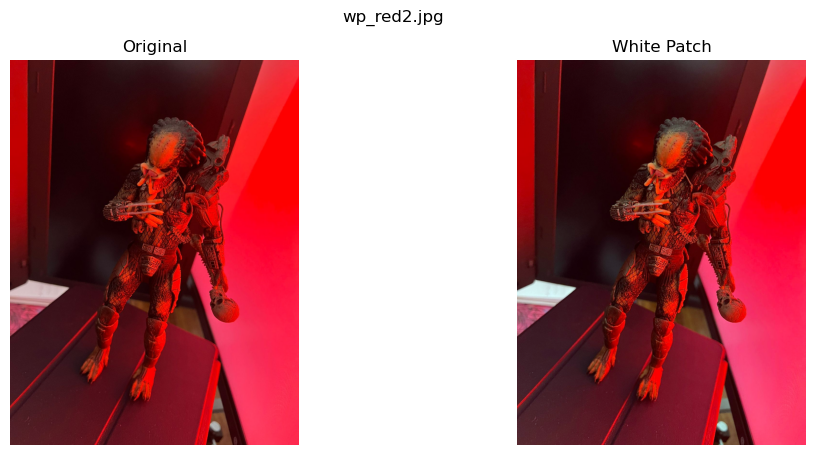

In [44]:
for resultado in resultados_wp:
    nombre = resultado["nombre"]
    original = resultado["original"]
    corregida = resultado["corregida"]

    # convertir BGR a RGB para visualizar correctamente con matplotlib
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    corregida_rgb = cv2.cvtColor(corregida, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(corregida_rgb)
    plt.title("White Patch")
    plt.axis("off")

    plt.suptitle(nombre)
    plt.show()

In [45]:
for resultado in resultados_wp:
    nombre = resultado["nombre"]
    original = resultado["original"]
    corregida = resultado["corregida"]

    B_o, G_o, R_o = cv2.split(original)
    B_c, G_c, R_c = cv2.split(corregida)

    print("Imagen:", nombre)
    print("Original  => Bmax:", B_o.max(), "Gmax:", G_o.max(), "Rmax:", R_o.max())
    print("Corregida => Bmax:", B_c.max(), "Gmax:", G_c.max(), "Rmax:", R_c.max())
    print("-" * 60)

Imagen: test_blue.png
Original  => Bmax: 200 Gmax: 138 Rmax: 165
Corregida => Bmax: 255 Gmax: 255 Rmax: 255
------------------------------------------------------------
Imagen: test_green.png
Original  => Bmax: 171 Gmax: 250 Rmax: 210
Corregida => Bmax: 255 Gmax: 255 Rmax: 255
------------------------------------------------------------
Imagen: test_red.png
Original  => Bmax: 175 Gmax: 157 Rmax: 247
Corregida => Bmax: 255 Gmax: 255 Rmax: 255
------------------------------------------------------------
Imagen: wp_blue.jpg
Original  => Bmax: 255 Gmax: 255 Rmax: 255
Corregida => Bmax: 255 Gmax: 255 Rmax: 255
------------------------------------------------------------
Imagen: wp_green.png
Original  => Bmax: 155 Gmax: 252 Rmax: 126
Corregida => Bmax: 255 Gmax: 255 Rmax: 255
------------------------------------------------------------
Imagen: wp_green2.jpg
Original  => Bmax: 172 Gmax: 255 Rmax: 170
Corregida => Bmax: 255 Gmax: 255 Rmax: 255
--------------------------------------------------

### Análisis de resultados de White Patch

Al aplicar White Patch se observa que las imágenes con dominantes de color azul, verde o rojo tienden a compensarse parcialmente. Esto se nota especialmente en las imágenes de prueba `test_blue.png`, `test_green.png` y `test_red.png`, donde la dominante de iluminación disminuye y los colores quedan más equilibrados.

La verificación de los máximos por canal muestra que luego de la corrección, los canales B, G y R alcanzan el valor 255. Esto confirma que el algoritmo escaló cada canal de forma independiente usando como referencia su valor máximo, sin embargo, no todas las imágenes mejoran de la misma forma, en algunos casos, como `wp_blue.jpg`, los tres canales ya tenían valores máximos en 255 antes de aplicar el algoritmo, por ello la corrección visual es reducida. Esto muestra una limitación del método, si la imagen ya tiene zonas saturadas que no representan un blanco real white Patch puede no corregir adecuadamente la dominante de iluminación


## Parte 2: Histogramas de imágenes en escala de grises

Se leen las imágenes `img1_tp.png` e `img2_tp.png` utilizando OpenCV en escala de grises, luego se grafican sus histogramas para analizar la distribución de intensidades y comparar ambas imágenes

In [46]:
img1_gray = cv2.imread(str(img1_path), cv2.IMREAD_GRAYSCALE)
img2_gray = cv2.imread(str(img2_path), cv2.IMREAD_GRAYSCALE)
print("img1_tp.png:", img1_gray.shape, img1_gray.dtype)
print("img2_tp.png:", img2_gray.shape, img2_gray.dtype)

img1_tp.png: (288, 287) uint8
img2_tp.png: (288, 287) uint8


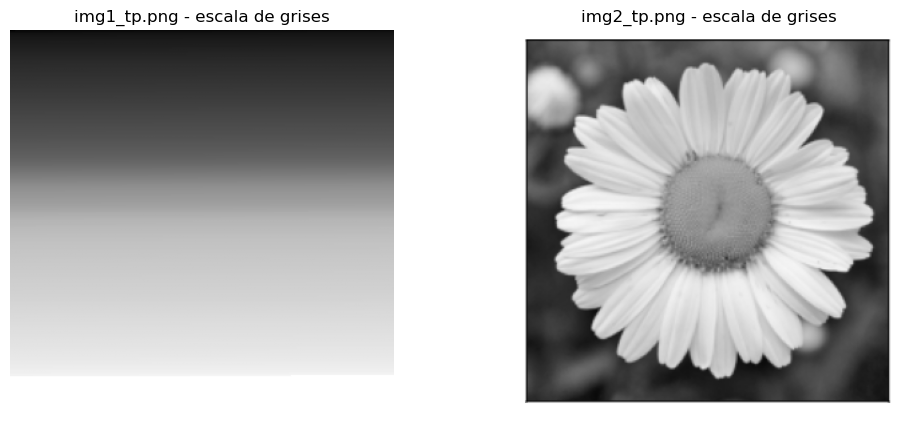

In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1_gray, cmap="gray")
plt.title("img1_tp.png - escala de grises")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_gray, cmap="gray")
plt.title("img2_tp.png - escala de grises")
plt.axis("off")

plt.show()

### Elección del número de bins

Se utilizaron 256 bins porque las imágenes están representadas en escala de grises de 8 bits esto significa que cada píxel puede tomar valores enteros entre 0 y 255

In [48]:
bins = 256

hist1 = cv2.calcHist([img1_gray], [0], None, [bins], [0, 256])
hist2 = cv2.calcHist([img2_gray], [0], None, [bins], [0, 256])

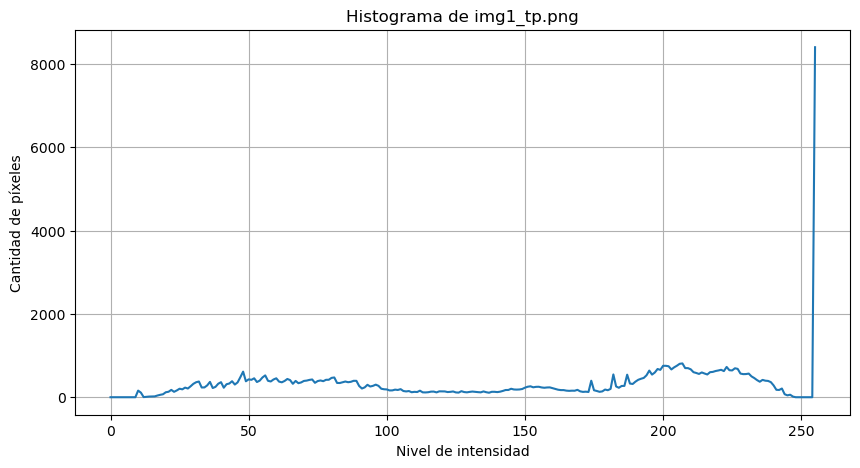

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(hist1)
plt.title("Histograma de img1_tp.png")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Cantidad de píxeles")
plt.grid()
plt.show()

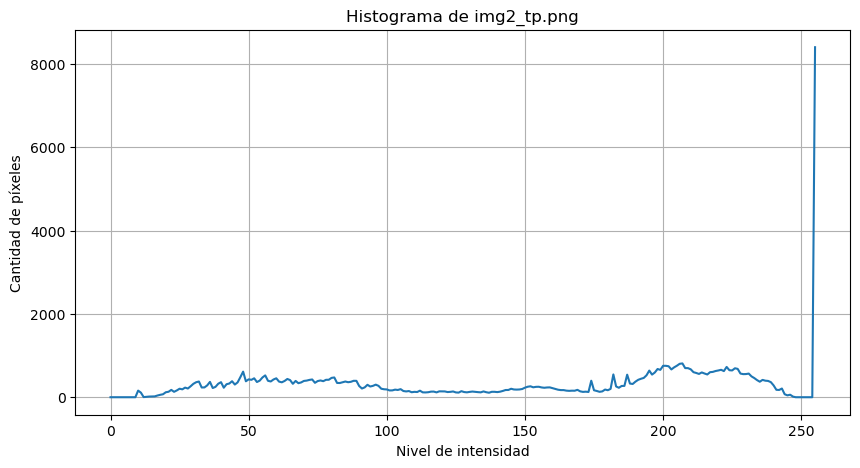

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(hist2)
plt.title("Histograma de img2_tp.png")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Cantidad de píxeles")
plt.grid()
plt.show()

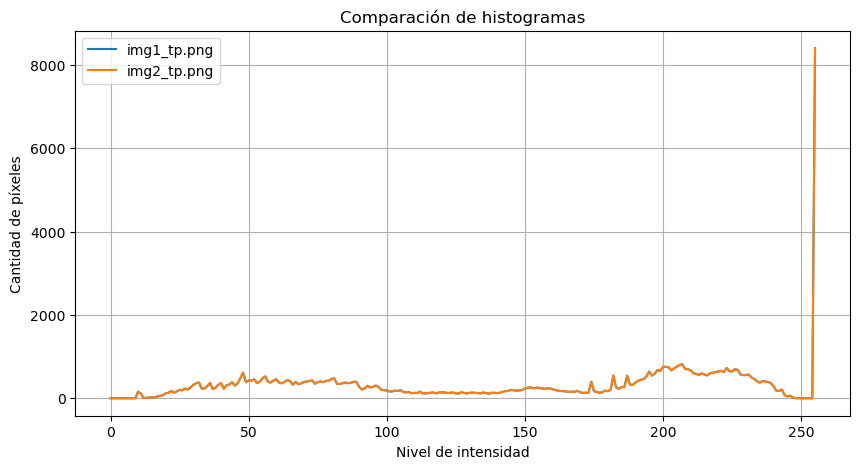

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(hist1, label="img1_tp.png")
plt.plot(hist2, label="img2_tp.png")
plt.title("Comparación de histogramas")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Cantidad de píxeles")
plt.legend()
plt.grid()
plt.show()

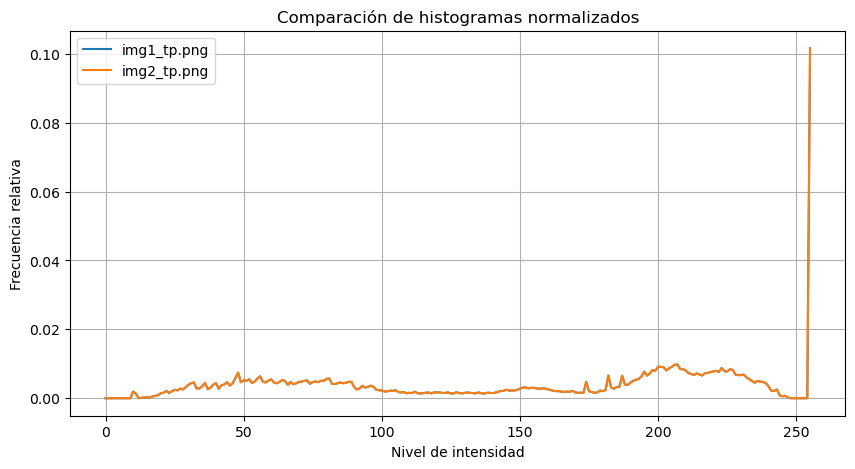

In [52]:
hist1_norm = hist1 / hist1.sum()
hist2_norm = hist2 / hist2.sum()

plt.figure(figsize=(10, 5))
plt.plot(hist1_norm, label="img1_tp.png")
plt.plot(hist2_norm, label="img2_tp.png")
plt.title("Comparación de histogramas normalizados")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia relativa")
plt.legend()
plt.grid()
plt.show()

### Análisis y comparación de histogramas

Las dos imágenes se ven visualmente diferentes: `img1_tp.png` parece una imagen generada de tonos de gris, mientras que `img2_tp.png` corresponde a una imagen de una flor en escala de grises, al comparar sus histogramas se observa que las distribuciones de intensidad son iguales esto significa que ambas imágenes son similares en píxeles para cada nivel de gris, aunque la ubicación de esos píxeles sea distinta

### Uso de histogramas como features

en este caso se observa que dos imágenes distintas pueden tener histogramas iguales, esto puede ser porque no sabe si los píxeles claros u oscuros pertenecen a una flor, a un fondo o a un borde.

## Conclusiones
### Parte 1
Se implementó el algoritmo White Patch y se aplicó sobre las imágenes de la carpeta `white_patch`. En los casos con dominantes de color el algoritmo compenso la iluminación hasta que su valor máximo llegue a 255.

se observó que el método tiene limitaciones, si los valores máximos de los canales no corresponden a una referencia real de blanco, o si presenta saturación, la corrección puede ser pequeña o no tan visible.

### Parte 2
Se analizaron los histogramas de `img1_tp.png` e `img2_tp.png` que aunque las imágenes son visualmente distintas sus histogramas resultaron muy similares esto demuestra que el histograma describe la distribución de intensidades, pero no información espacial.

Por eso los histogramas pueden servir como características simples, pero no son suficientes por sí solos si la ubicación de los objetos es importante